In [13]:
import numpy as np
from scipy import fft, signal
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib.animation

from IPython.display import HTML, Image

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']

import io
import soundfile as sf
from urllib.request import urlopen

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

# https://thewolfsound.com/bilinear-transform/




Partial tracking is the process of detecting single sinusoidal components in a signal and obtaining their individual amplitude, frequency and phase trajectories.
For monophonic signals, this is a straight-forward procedure:

- 1: STFT
- 2: Fundamental Frequency Estimation
- 3: Peak Detection
- 4: Peak Continuation

The following plots show the amplitude, frequency and phase trajectories for a violin sound.


 -----


 
 ## Partial Amplitude Trajectories
 

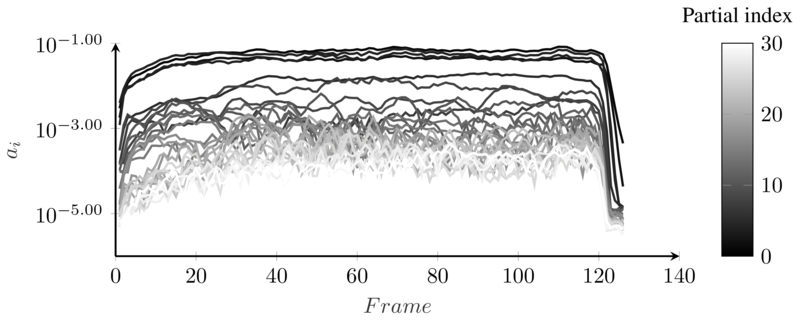

In [35]:
display(Image("../images/spectral_analysis/amplitudes.png"))

 -----
 
 ## Partial Frequency Trajectories
 

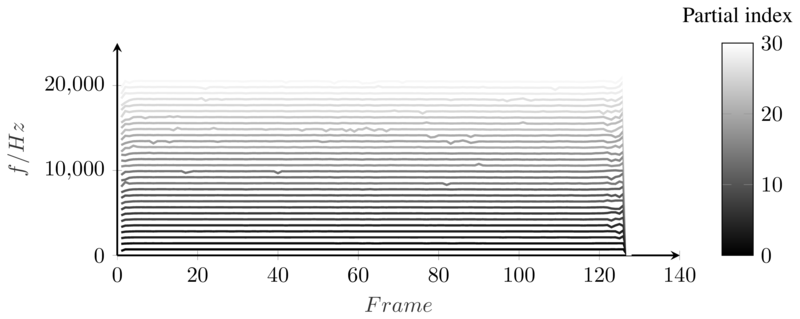

In [36]:
display(Image("../images/spectral_analysis/frequencies.png"))

           

 -----
 
 ## Partial Phase Trajectories
 

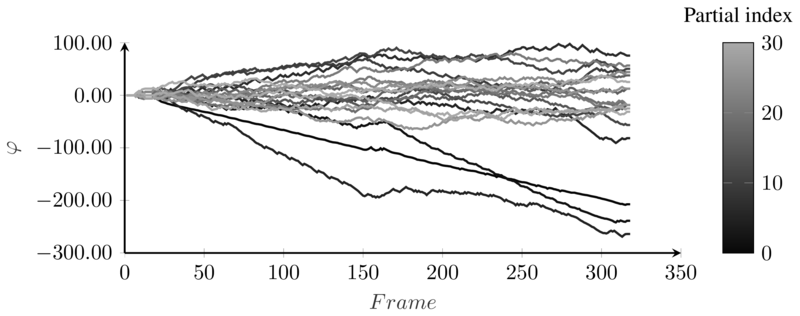

In [37]:

display(Image("../images/spectral_analysis/phases.png"))



-----

# Partial Peak Estimation

For every analysis frame $X_n$ we first estimate the fundamental frequency $f_0$.
It makes senste to zero-pad the frames before FFT and peak picking to allow for a more accurate peak detection 
of the partials.

Afterwards, we can get the amplitude $a_i$ based on $f_0$ and the fundamental frequency:

$$
a_i = \left| H \left[ i \frac{f_s}{\mathrm{Lag}_{max}} \right] \right|
$$

We need to define a **search area** around the calculated position of each peak to compensate for errors in the $f_0$ estimation and signal deviations. 

In a strictly harmonic model, we do not have to estimate the **partial frequencies**. We can still achieve decent synthesis results with this restriction.

The **phase** of a partial cannot simply be read from the peak in most cases.
It can best be estimated by minimizing the error between the original signal and partials with the estimated amplitude and frequency at phases between $\pi$ and $\pi$. 


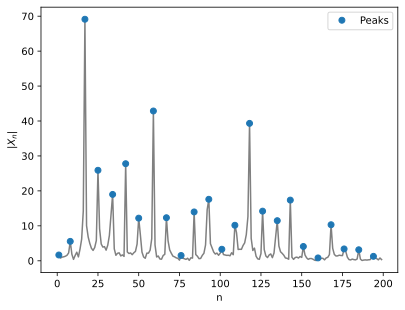

In [38]:
url = 'https://ringbuffer.org/download/ringbuffer_data/Sound_Synthesis_Introduction/Audio/SampLib_BuK_04.mp3'
x, fs = sf.read(io.BytesIO(urlopen(url).read()))

x1 = x[50000:50000+2048]
X1 = fft.fft(x1)

Xa = abs(X1[0:200])
peaks, _ = sp.signal.find_peaks(Xa, distance=5)

plt.plot(Xa, 'gray')
plt.plot(peaks,Xa[peaks],linestyle=' ', marker='o', label='Peaks')
plt.xlabel('n')
plt.ylabel('$|X_n|$')
plt.legend();


----

# Quadratic Interpolation

The detection of local maxima in a spectrum is limited to the DFT support points without further processing.
Even with zero-padding, further steps can improve the pitch estimation.
The following example shows this for a 25 Hz sinusoid at a sampling rate of 100 Hz.


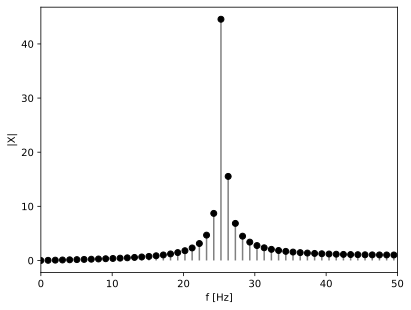

In [56]:

fs = 100
t  = np.linspace(0,1,fs)

f0 = 25
x  = np.sin(2*np.pi*fs*f0*t)

 

X = abs(np.fft.fft(x))
#X = np.fft.fftshift(X)
f = np.linspace(0,fs,len(X))

fig, ax = plt.subplots()


markerline, stemlines, baseline = plt.stem(f,X, 'gray', markerfmt='ko', )

baseline.set_visible(False)



#col   = LineCollection(verts)
#ax.add_collection(col)

ax.set_xlabel('f [Hz]')
ax.set_ylabel('|X|')
ax.set_xlim(0,fs/2);
#ax.set_ylim(None, 110);

 


Quadratic or parabolic interpolation can be used to estimate the true peak of the sinusoid. using the detected maximum $a$ and its upper and lower neighbor bin.

$$
p = 0.5  (\alpha-\gamma)/(\alpha-2\beta+\gamma)
$$

$$
a^* =  \beta-1/4(\alpha-\gamma)
$$


[More details on JOS Website](https://ccrma.stanford.edu/~jos/parshl/Peak_Detection_Steps_3.html#sec:peakdet)